# 04 - Final CVE-CWE dataset validation

This notebook validates the dataset obtained after hierarchy-aware CWE aggregation with a minimum threshold of **200 examples per class**.

## Objectives

- check integrity, duplicates, and missing values;
- check that no NVD pseudo-labels remain;
- verify that all classes have at least 200 CVEs;
- analyze the CWE distribution;
- measure multilabel cardinality and density;
- analyze removed CWEs and CVEs;
- produce a final report and save figures and tables.

The notebook is designed to work even if some column names change slightly.


In [1]:
from __future__ import annotations

import ast
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

MIN_SUPPORT = 200

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "final_cve": DATA_DIR / "cve_dataset_hierarchy_merged.csv",
    "final_cwe": DATA_DIR / "cwe_hierarchy_merged_counts.csv",
    "removed_cwe": DATA_DIR / "cwe_removed_rare_labels.csv",
    "removed_cve": DATA_DIR / "cve_removed_without_cwe.csv",
}

FILES

{'final_cve': WindowsPath('c:/Users/MartinaCapone/Desktop/ML_project/data/cve_dataset_hierarchy_merged.csv'),
 'final_cwe': WindowsPath('c:/Users/MartinaCapone/Desktop/ML_project/data/cwe_hierarchy_merged_counts.csv'),
 'removed_cwe': WindowsPath('c:/Users/MartinaCapone/Desktop/ML_project/data/cwe_removed_rare_labels.csv'),
 'removed_cve': WindowsPath('c:/Users/MartinaCapone/Desktop/ML_project/data/cve_removed_without_cwe.csv')}

## 1. Helper functions

The following functions:

- automatically identify columns;
- parse CWE lists stored as JSON, Python lists, or comma-separated strings;
- normalize identifiers to the `CWE-N` format;
- allow the notebook to adapt to small variations in CSV format.

In [2]:
def find_column(
    df: pd.DataFrame,
    candidates: list[str],
    *,
    required: bool = True,
) -> str | None:
    """Find a column using candidate names, ignoring case."""
    normalized = {str(column).strip().lower(): column for column in df.columns}

    for candidate in candidates:
        key = candidate.strip().lower()
        if key in normalized:
            return normalized[key]

    for column in df.columns:
        lowered = str(column).strip().lower()
        if any(candidate.lower() in lowered for candidate in candidates):
            return column

    if required:
        raise KeyError(
            f"No column found among {candidates}. "
            f"Available columns: {list(df.columns)}"
        )
    return None


def normalize_cwe_id(value: object) -> str | None:
    """Normalize a real CWE identifier to the CWE-N format."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    text = str(value).strip().upper()
    match = re.fullmatch(r"(?:CWE[-_ ]?)?(\d+)", text)

    if not match:
        return None

    return f"CWE-{int(match.group(1))}"


def parse_cwe_labels(value: object) -> list[str]:
    """Convert different CWE-list formats into a normalized list."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []

    if isinstance(value, (list, tuple, set, np.ndarray)):
        raw_items = list(value)
    else:
        text = str(value).strip()
        if not text:
            return []

        raw_items = None

        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(text)
                if isinstance(parsed, (list, tuple, set)):
                    raw_items = list(parsed)
                    break
            except (ValueError, SyntaxError, TypeError, json.JSONDecodeError):
                pass

        if raw_items is None:
            raw_items = re.findall(r"CWE[-_ ]?\d+", text, flags=re.IGNORECASE)
            if not raw_items:
                raw_items = re.split(r"[,;|]", text)

    labels = []
    for item in raw_items:
        normalized = normalize_cwe_id(item)
        if normalized is not None:
            labels.append(normalized)

    return sorted(set(labels), key=lambda label: int(label.split("-")[1]))


def save_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path


def print_check(condition: bool, success: str, failure: str) -> None:
    symbol = "✓" if condition else "✗"
    print(f"{symbol} {success if condition else failure}")

## 2. File checks and loading

In [3]:
missing_files = [path for path in FILES.values() if not path.exists()]

if missing_files:
    formatted = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "Not all required files were found:\n"
        f"{formatted}\n\n"
        "Run the notebook from the project root or from the notebooks folder."
    )

datasets = {
    name: pd.read_csv(path, low_memory=False)
    for name, path in FILES.items()
}

for name, dataframe in datasets.items():
    print(f"{name:>12}: {dataframe.shape[0]:>8} rows × {dataframe.shape[1]:>3} columns")
    print(f"             {list(dataframe.columns)}")

   final_cve:   291935 rows ×   3 columns
             ['cve_id', 'description', 'cwe_ids']
   final_cwe:      150 rows ×  11 columns
             ['cwe_id', 'name', 'abstraction', 'status', 'mapping_usage', 'primary_parent', 'other_parents', 'children', 'depth', 'cve_count', 'meets_min_support']
 removed_cwe:       47 rows ×   3 columns
             ['cwe_id', 'cve_count', 'reason']
 removed_cve:    50296 rows ×   3 columns
             ['cve_id', 'description', 'cwe_ids']


In [4]:
df_cve = datasets["final_cve"].copy()
df_cwe = datasets["final_cwe"].copy()
df_removed_cwe = datasets["removed_cwe"].copy()
df_removed_cve = datasets["removed_cve"].copy()

display(df_cve.head())
display(df_cwe.head())

,cve_id,description,cwe_ids
0,CVE-2002-0012,Vulnerabilities in a large number of SNMP impl...,"[""CWE-264""]"
1,CVE-2002-0013,Vulnerabilities in the SNMPv1 request handling...,"[""CWE-264""]"
2,CVE-2002-0049,Microsoft Exchange Server 2000 System Attendan...,"[""CWE-269""]"
3,CVE-2002-0053,Buffer overflow in SNMP agent service in Windo...,"[""CWE-119""]"
4,CVE-2002-0054,SMTP service in (1) Microsoft Windows 2000 and...,"[""CWE-294""]"


,cwe_id,name,abstraction,status,mapping_usage,primary_parent,other_parents,children,depth,cve_count,meets_min_support
0,CWE-79,Improper Neutralization of Input During Web Pa...,Base,Stable,Allowed,CWE-74,[],"[""CWE-80"", ""CWE-81"", ""CWE-83"", ""CWE-84"", ""CWE-...",2.0,45536,True
1,CWE-89,Improper Neutralization of Special Elements us...,Base,Stable,Allowed,CWE-943,[],"[""CWE-564""]",3.0,19861,True
2,CWE-787,Out-of-bounds Write,Base,Draft,Allowed-with-Review,CWE-119,[],"[""CWE-120"", ""CWE-121"", ""CWE-122"", ""CWE-123"", ""...",3.0,14375,True
3,CWE-119,Improper Restriction of Operations within the ...,Class,Stable,Discouraged,CWE-118,[],"[""CWE-125"", ""CWE-466"", ""CWE-786"", ""CWE-787"", ""...",2.0,14350,True
4,CWE-20,Improper Input Validation,Class,Stable,Discouraged,CWE-707,[],"[""CWE-179"", ""CWE-622"", ""CWE-1173"", ""CWE-1284"",...",1.0,13018,True


## 3. Column detection and label parsing

In [5]:
CVE_ID_COL = find_column(
    df_cve,
    ["cve_id", "cve", "id"],
)

LABELS_COL = find_column(
    df_cve,
    ["cwe_ids", "cwe_labels", "labels", "cwes", "cwe_id"],
)

DESCRIPTION_COL = find_column(
    df_cve,
    ["description", "description_text", "text"],
    required=False,
)

DATE_COL = find_column(
    df_cve,
    ["published_date", "published", "date", "year"],
    required=False,
)

CWE_ID_COL = find_column(
    df_cwe,
    ["cwe_id", "cwe", "label"],
)

COUNT_COL = find_column(
    df_cwe,
    ["cve_count", "count", "support", "frequency", "n_cve"],
)

ABSTRACTION_COL = find_column(
    df_cwe,
    ["abstraction", "type"],
    required=False,
)

print("Colonne individuate:")
print(f"- ID CVE:       {CVE_ID_COL}")
print(f"- CWE per CVE:  {LABELS_COL}")
print(f"- Descrizione:  {DESCRIPTION_COL}")
print(f"- Data/anno:    {DATE_COL}")
print(f"- ID CWE:       {CWE_ID_COL}")
print(f"- Conteggio:    {COUNT_COL}")
print(f"- Abstraction:  {ABSTRACTION_COL}")

Colonne individuate:
- ID CVE:       cve_id
- CWE per CVE:  cwe_ids
- Descrizione:  description
- Data/anno:    None
- ID CWE:       cwe_id
- Conteggio:    cve_count
- Abstraction:  abstraction


In [6]:
df_cve["_parsed_cwe_labels"] = df_cve[LABELS_COL].apply(parse_cwe_labels)
df_cve["_n_labels"] = df_cve["_parsed_cwe_labels"].str.len()

df_cwe[CWE_ID_COL] = df_cwe[CWE_ID_COL].apply(normalize_cwe_id)
df_cwe[COUNT_COL] = pd.to_numeric(df_cwe[COUNT_COL], errors="coerce")

display(
    df_cve[[CVE_ID_COL, LABELS_COL, "_parsed_cwe_labels", "_n_labels"]].head(10)
)

,cve_id,cwe_ids,_parsed_cwe_labels,_n_labels
0,CVE-2002-0012,"[""CWE-264""]",[CWE-264],1
1,CVE-2002-0013,"[""CWE-264""]",[CWE-264],1
2,CVE-2002-0049,"[""CWE-269""]",[CWE-269],1
3,CVE-2002-0053,"[""CWE-119""]",[CWE-119],1
4,CVE-2002-0054,"[""CWE-294""]",[CWE-294],1
5,CVE-2002-0055,"[""CWE-669""]",[CWE-669],1
6,CVE-2002-0062,"[""CWE-120""]",[CWE-120],1
7,CVE-2002-0059,"[""CWE-415""]",[CWE-415],1
8,CVE-2002-0070,"[""CWE-119""]",[CWE-119],1
9,CVE-2002-0080,"[""CWE-269""]",[CWE-269],1


## 4. Integrity checks

This section checks:

- duplicate rows;
- duplicate CVE IDs;
- CVEs without labels;
- missing descriptions;
- missing or invalid CWE counts.


In [8]:
def make_hashable(value):
    """Convert lists, dictionaries, and sets into pandas-comparable values."""
    if isinstance(value, list):
        return tuple(make_hashable(item) for item in value)
    if isinstance(value, tuple):
        return tuple(make_hashable(item) for item in value)
    if isinstance(value, set):
        return tuple(sorted(make_hashable(item) for item in value))
    if isinstance(value, dict):
        return tuple(
            sorted((key, make_hashable(item)) for key, item in value.items())
        )
    return value


hashable_df = df_cve.apply(
    lambda column: column.map(make_hashable)
)

integrity_checks = {
    "Duplicate rows in the final dataset": int(
        hashable_df.duplicated().sum()
    ),
    "Duplicate CVE IDs": int(
        df_cve[CVE_ID_COL].duplicated().sum()
    ),
    "Missing CVE IDs": int(
        df_cve[CVE_ID_COL].isna().sum()
    ),
    "CVEs without CWE after parsing": int(
        (df_cve["_n_labels"] == 0).sum()
    ),
    "Missing CWE counts": int(
        df_cwe[COUNT_COL].isna().sum()
    ),
    "Missing/invalid CWE IDs": int(
        df_cwe[CWE_ID_COL].isna().sum()
    ),
}

if DESCRIPTION_COL is not None:
    empty_descriptions = (
        df_cve[DESCRIPTION_COL]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    integrity_checks["Missing or empty descriptions"] = int(
        empty_descriptions
    )

integrity_table = (
    pd.Series(integrity_checks, name="Value")
    .rename_axis("Check")
    .reset_index()
)

display(integrity_table)

integrity_table.to_csv(
    TABLES_DIR / "integrity_checks.csv",
    index=False,
)

,Check,Value
0,Duplicate rows in the final dataset,0
1,Duplicate CVE IDs,0
2,Missing CVE IDs,0
3,CVEs without CWE after parsing,0
4,Missing CWE counts,0
5,Missing/invalid CWE IDs,0
6,Missing or empty descriptions,0


In [9]:
print_check(
    integrity_checks["Duplicate CVE IDs"] == 0,
    "No duplicate CVE IDs are present.",
    "Duplicate CVE IDs are present.",
)

print_check(
    integrity_checks["CVEs without CWE after parsing"] == 0,
    "All CVEs have at least one valid CWE.",
    "Some CVEs have no valid CWE.",
)

print_check(
    integrity_checks["Missing CWE counts"] == 0,
    "All CWE counts are numeric.",
    "Some CWE counts are missing or non-numeric.",
)

✓ No duplicate CVE IDs are present.
✓ All CVEs have at least one valid CWE.
✓ All CWE counts are numeric.


## 5. NVD pseudo-label check

In [10]:
raw_label_text = df_cve[LABELS_COL].fillna("").astype(str)

pseudo_label_counts = {
    "NVD-CWE-noinfo": int(
        raw_label_text.str.contains("NVD-CWE-noinfo", case=False, regex=False).sum()
    ),
    "NVD-CWE-Other": int(
        raw_label_text.str.contains("NVD-CWE-Other", case=False, regex=False).sum()
    ),
}

pseudo_table = (
    pd.Series(pseudo_label_counts, name="Row_occurrences")
    .rename_axis("Pseudo_label")
    .reset_index()
)

display(pseudo_table)

print_check(
    sum(pseudo_label_counts.values()) == 0,
    "No NVD pseudo-labels remain.",
    "NVD pseudo-labels are still present.",
)

,Pseudo_label,Row_occurrences
0,NVD-CWE-noinfo,0
1,NVD-CWE-Other,0


✓ No NVD pseudo-labels remain.


## 6. Independent class-count verification

Counts are recomputed directly from the final CVE dataset and compared with `cwe_hierarchy_merged_counts.csv`.

In [11]:
recomputed_counts = Counter(
    label
    for labels in df_cve["_parsed_cwe_labels"]
    for label in labels
)

df_recomputed = (
    pd.DataFrame(
        recomputed_counts.items(),
        columns=[CWE_ID_COL, "recomputed_count"],
    )
    .sort_values("recomputed_count", ascending=False)
    .reset_index(drop=True)
)

count_comparison = (
    df_cwe[[CWE_ID_COL, COUNT_COL]]
    .dropna(subset=[CWE_ID_COL])
    .merge(df_recomputed, on=CWE_ID_COL, how="outer")
)

count_comparison[COUNT_COL] = count_comparison[COUNT_COL].fillna(0).astype(int)
count_comparison["recomputed_count"] = (
    count_comparison["recomputed_count"].fillna(0).astype(int)
)
count_comparison["difference"] = (
    count_comparison["recomputed_count"] - count_comparison[COUNT_COL]
)

display(count_comparison.head(20))

mismatches = count_comparison[count_comparison["difference"] != 0]
print(f"Classes with mismatched counts: {len(mismatches)}")

print_check(
    mismatches.empty,
    "The counts in the summary file match the recomputed counts.",
    "There are differences between the declared and recomputed counts.",
)

count_comparison.to_csv(
    TABLES_DIR / "cwe_count_comparison.csv",
    index=False,
)

,cwe_id,cve_count,recomputed_count,difference
0,CWE-1021,398,398,0
1,CWE-116,607,607,0
2,CWE-1188,315,315,0
3,CWE-119,14350,14350,0
4,CWE-120,4301,4301,0
5,CWE-121,3506,3506,0
6,CWE-122,2515,2515,0
7,CWE-1236,298,298,0
8,CWE-125,9053,9053,0
9,CWE-126,474,474,0


Classes with mismatched counts: 0
✓ The counts in the summary file match the recomputed counts.


## 7. Minimum-threshold check

In [12]:
final_class_count = int(len(df_recomputed))
minimum_found = int(df_recomputed["recomputed_count"].min())
maximum_found = int(df_recomputed["recomputed_count"].max())
classes_below_threshold = df_recomputed[
    df_recomputed["recomputed_count"] < MIN_SUPPORT
].copy()

print(f"Required minimum threshold: {MIN_SUPPORT}")
print(f"Minimum support found: {minimum_found}")
print(f"Maximum support found: {maximum_found}")
print(f"Number of final classes:  {final_class_count}")
print(f"Classes below threshold:      {len(classes_below_threshold)}")

print_check(
    classes_below_threshold.empty,
    f"All classes have at least {MIN_SUPPORT} examples.",
    f"Some classes have fewer than {MIN_SUPPORT} examples.",
)

if not classes_below_threshold.empty:
    display(classes_below_threshold)

Required minimum threshold: 200
Minimum support found: 200
Maximum support found: 45536
Number of final classes:  150
Classes below threshold:      0
✓ All classes have at least 200 examples.


## 8. Descriptive statistics for the CWE distribution

In [13]:
percentiles = [0.00, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
support_stats = (
    df_recomputed["recomputed_count"]
    .quantile(percentiles)
    .rename_axis("Percentile")
    .reset_index(name="CVE_count")
)

support_stats["Percentile"] = support_stats["Percentile"].map(
    lambda value: f"{value:.0%}"
)
support_stats["CVE_count"] = support_stats["CVE_count"].round(2)

display(support_stats)
support_stats.to_csv(TABLES_DIR / "class_support_percentiles.csv", index=False)

,Percentile,CVE_count
0,0%,200.00
1,25%,335.00
2,50%,604.00
3,75%,1759.75
4,90%,5419.00
5,95%,9251.55
6,99%,17172.86
7,100%,45536.00


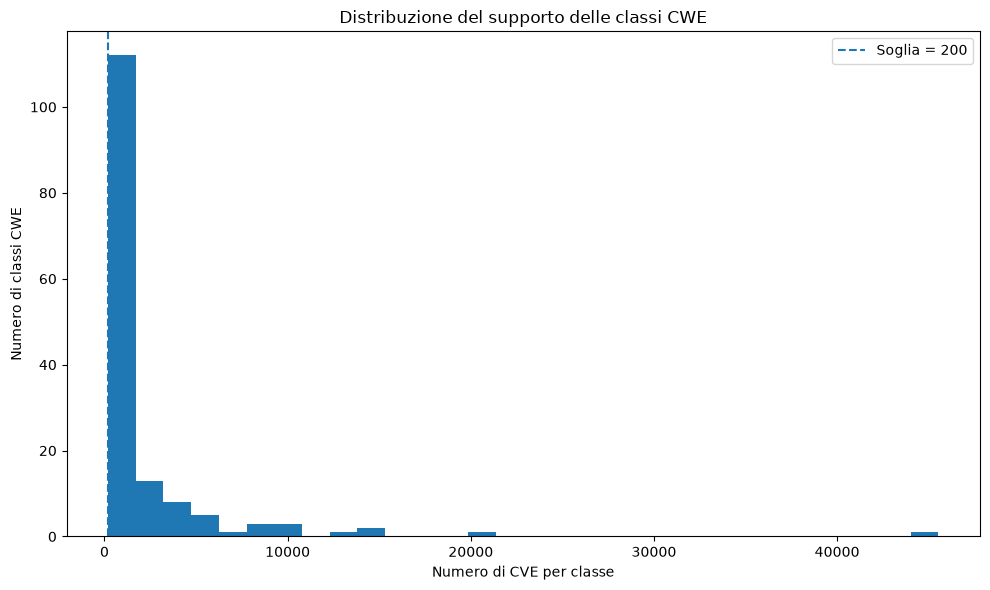

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\class_support_histogram.png


In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df_recomputed["recomputed_count"], bins=30)
plt.xlabel("Number of CVEs per class")
plt.ylabel("Number of CWE classes")
plt.title("CWE class support distribution")
plt.axvline(MIN_SUPPORT, linestyle="--", label=f"Threshold = {MIN_SUPPORT}")
plt.legend()
histogram_path = save_figure("class_support_histogram.png")
plt.show()

print(f"Figure saved to: {histogram_path}")

C:\Users\MartinaCapone\AppData\Local\Temp\ipykernel_14668\1055280596.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_recomputed["recomputed_count"], vert=False)


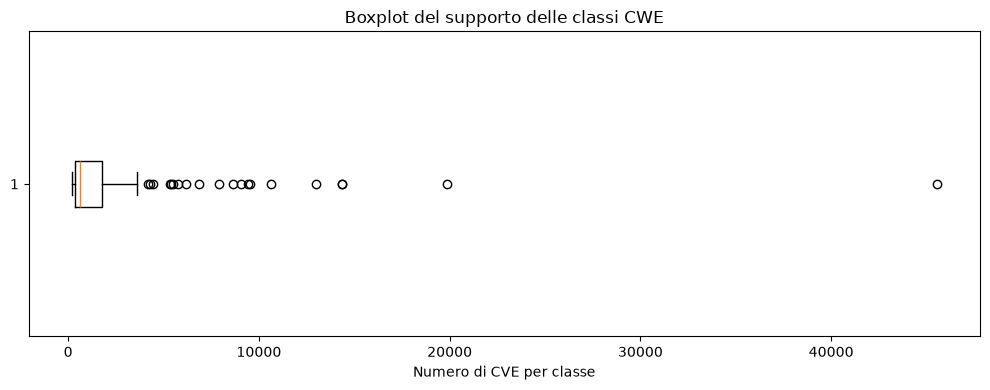

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\class_support_boxplot.png


In [15]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_recomputed["recomputed_count"], vert=False)
plt.xlabel("Number of CVEs per class")
plt.title("Boxplot of CWE class support")
boxplot_path = save_figure("class_support_boxplot.png")
plt.show()

print(f"Figure saved to: {boxplot_path}")

## 9. Class long tail

CWEs are ordered from most frequent to least frequent. The horizontal line represents the minimum threshold.


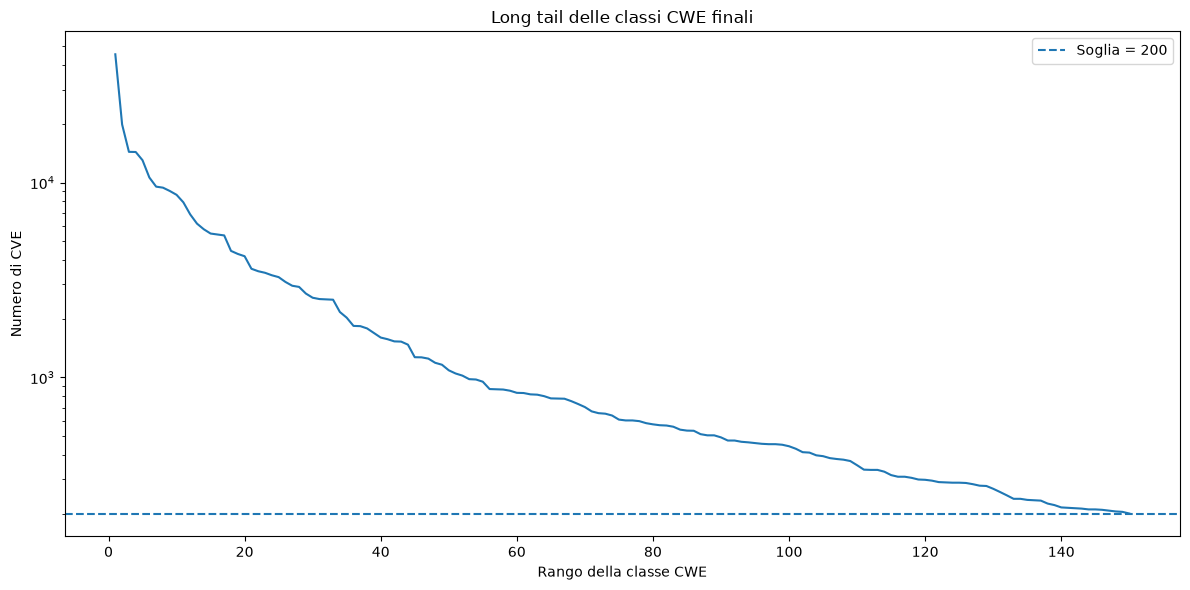

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\cwe_long_tail.png


In [16]:
ranked_counts = df_recomputed.sort_values(
    "recomputed_count",
    ascending=False,
).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(
    np.arange(1, len(ranked_counts) + 1),
    ranked_counts["recomputed_count"],
)
plt.axhline(MIN_SUPPORT, linestyle="--", label=f"Threshold = {MIN_SUPPORT}")
plt.xlabel("CWE class rank")
plt.ylabel("Number of CVEs")
plt.title("Long tail of final CWE classes")
plt.yscale("log")
plt.legend()
long_tail_path = save_figure("cwe_long_tail.png")
plt.show()

print(f"Figure saved to: {long_tail_path}")

## 10. Most and least frequent classes


In [17]:
top_classes = ranked_counts.head(20)
bottom_classes = ranked_counts.tail(20).sort_values("recomputed_count")

print("20 most frequent CWEs")
display(top_classes)

print("20 least frequent CWEs")
display(bottom_classes)

top_classes.to_csv(TABLES_DIR / "top_20_cwe.csv", index=False)
bottom_classes.to_csv(TABLES_DIR / "bottom_20_cwe.csv", index=False)

20 most frequent CWEs


,cwe_id,recomputed_count
0,CWE-79,45536
1,CWE-89,19861
2,CWE-787,14375
3,CWE-119,14350
4,CWE-20,13018
5,CWE-200,10618
6,CWE-22,9528
7,CWE-352,9414
8,CWE-125,9053
9,CWE-862,8651


20 least frequent CWEs


,cwe_id,recomputed_count
149,CWE-252,200
148,CWE-917,204
147,CWE-457,205
146,CWE-131,207
145,CWE-494,209
143,CWE-256,210
144,CWE-193,210
142,CWE-822,212
141,CWE-573,213
140,CWE-1391,214


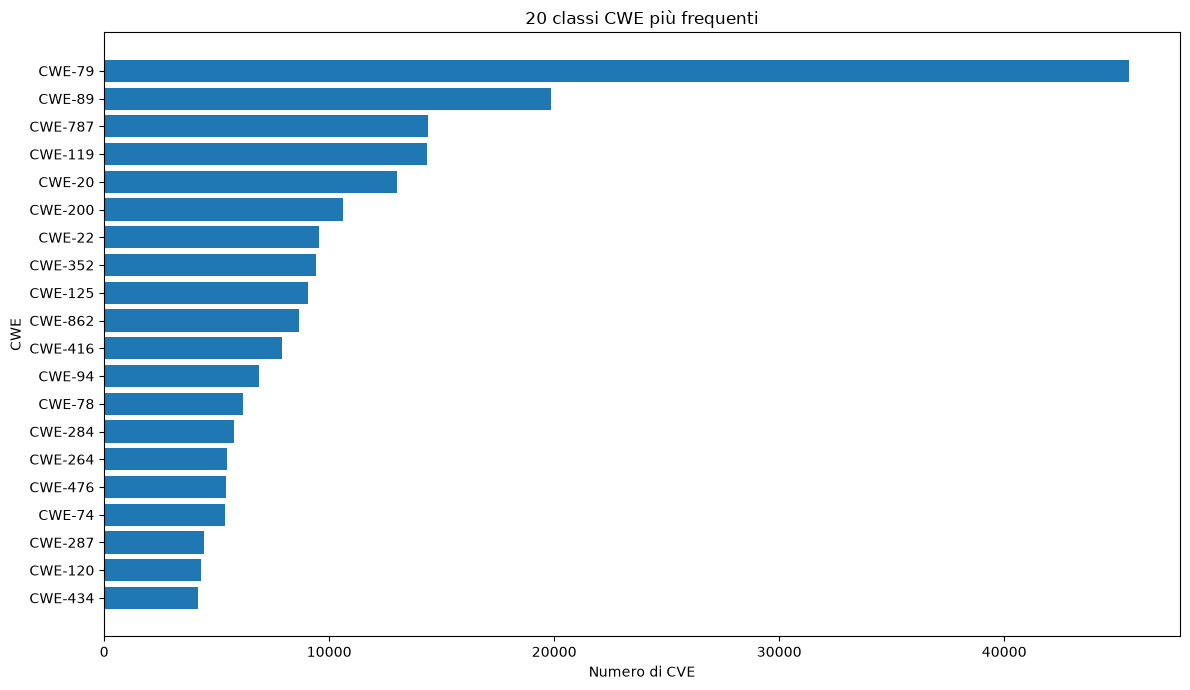

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\top_20_cwe.png


In [18]:
plt.figure(figsize=(12, 7))
plt.barh(
    top_classes[CWE_ID_COL][::-1],
    top_classes["recomputed_count"][::-1],
)
plt.xlabel("Number of CVEs")
plt.ylabel("CWE")
plt.title("20 most frequent CWE classes")
top_classes_path = save_figure("top_20_cwe.png")
plt.show()

print(f"Figure saved to: {top_classes_path}")

## 11. Multilabel analysis

- **Label cardinality**: average number of labels per CVE.
- **Label density**: cardinality divided by the total number of classes.


In [19]:
n_samples = len(df_cve)
n_labels = final_class_count
total_associations = int(df_cve["_n_labels"].sum())

label_cardinality = (
    total_associations / n_samples
    if n_samples
    else np.nan
)
label_density = (
    label_cardinality / n_labels
    if n_labels
    else np.nan
)

multilabel_summary = pd.DataFrame(
    {
        "Metric": [
            "CVE count",
            "CWE class count",
            "Total CVE-CWE associations",
            "Minimum labels per CVE",
            "Maximum labels per CVE",
            "Median labels per CVE",
            "Label cardinality",
            "Label density",
            "CVEs with more than one label",
            "Percentage of multilabel CVEs",
        ],
        "Value": [
            n_samples,
            n_labels,
            total_associations,
            int(df_cve["_n_labels"].min()),
            int(df_cve["_n_labels"].max()),
            float(df_cve["_n_labels"].median()),
            label_cardinality,
            label_density,
            int((df_cve["_n_labels"] > 1).sum()),
            float((df_cve["_n_labels"] > 1).mean() * 100),
        ],
    }
)

display(multilabel_summary)
multilabel_summary.to_csv(
    TABLES_DIR / "multilabel_summary.csv",
    index=False,
)

,Metric,Value
0,CVE count,291935.000000
1,CWE class count,150.000000
2,Total CVE-CWE associations,322946.000000
3,Minimum labels per CVE,1.000000
4,Maximum labels per CVE,8.000000
5,Median labels per CVE,1.000000
6,Label cardinality,1.106226
7,Label density,0.007375
8,CVEs with more than one label,29160.000000
9,Percentage of multilabel CVEs,9.988525


In [20]:
labels_per_cve = (
    df_cve["_n_labels"]
    .value_counts()
    .sort_index()
    .rename_axis("Label_count")
    .reset_index(name="CVE_count")
)
labels_per_cve["Percentage"] = (
    labels_per_cve["CVE_count"] / len(df_cve) * 100
)

display(labels_per_cve)
labels_per_cve.to_csv(
    TABLES_DIR / "labels_per_cve_distribution.csv",
    index=False,
)

,Label_count,CVE_count,Percentage
0,1,262775,90.011475
1,2,27554,9.438402
2,3,1413,0.484012
3,4,164,0.056177
4,5,16,0.005481
5,6,5,0.001713
6,7,6,0.002055
7,8,2,0.000685


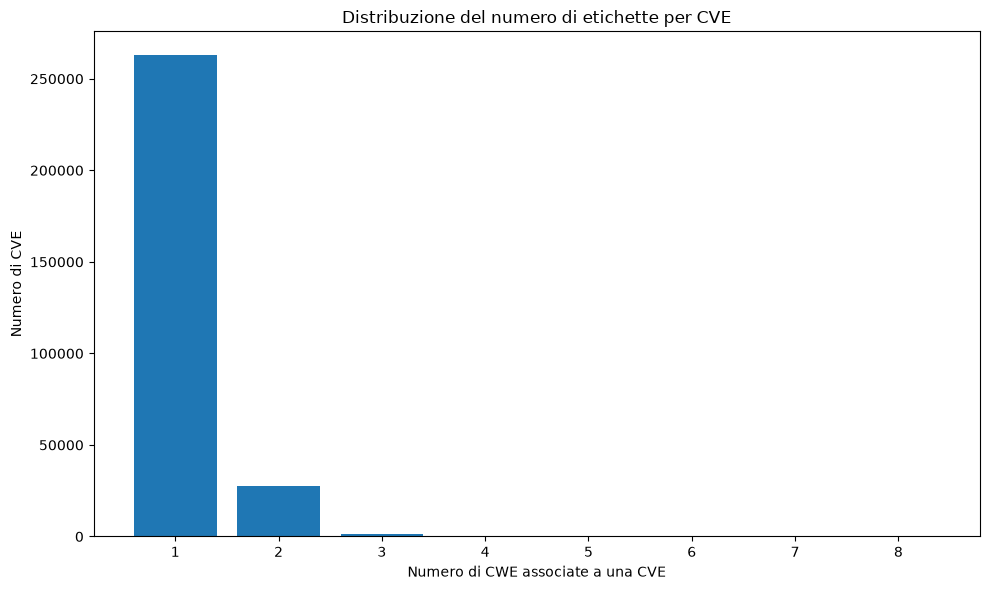

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\labels_per_cve.png


In [21]:
plt.figure(figsize=(10, 6))
plt.bar(
    labels_per_cve["Label_count"].astype(str),
    labels_per_cve["CVE_count"],
)
plt.xlabel("Number of CWEs associated with a CVE")
plt.ylabel("Number of CVEs")
plt.title("Distribution of the number of labels per CVE")
labels_per_cve_path = save_figure("labels_per_cve.png")
plt.show()

print(f"Figure saved to: {labels_per_cve_path}")

## 12. Distribution by abstraction

This section runs only if the final CWE file contains the `abstraction` column.

,abstraction,CWE_count,Total_associations,Mean_CVEs,Median_CVEs,Min_CVEs,Max_CVEs
0,Base,77,177683,2307.571429,596.0,200,45536
1,Class,44,92215,2095.795455,653.0,213,14350
2,Variant,12,20531,1710.916667,708.0,205,7915
3,NaN,8,13651,1706.375000,1012.5,234,5473
4,Pillar,7,9041,1291.571429,504.0,288,5758
5,Compound,2,9825,4912.500000,4912.5,411,9414


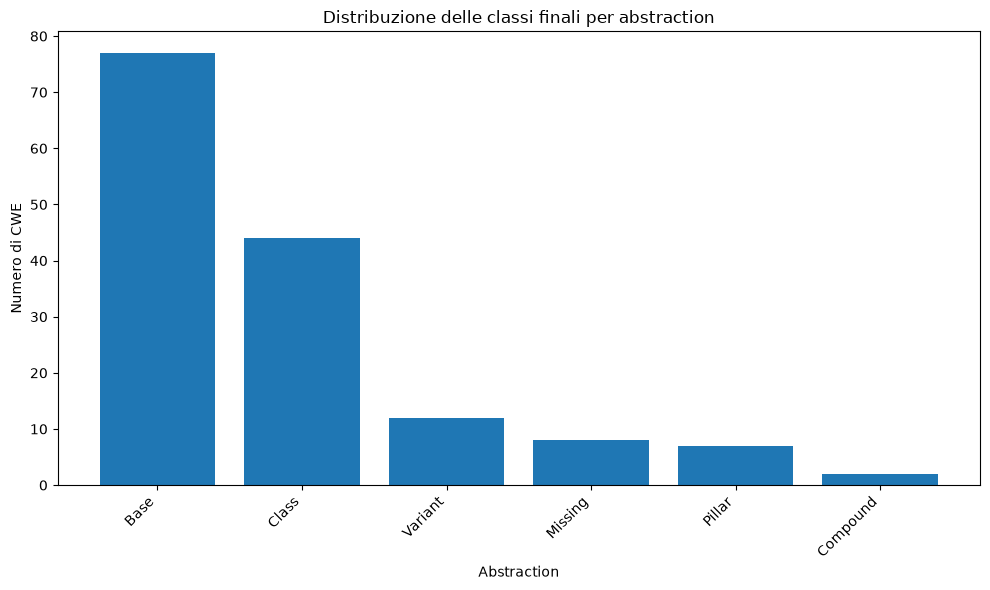

Figure saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\figures\cwe_by_abstraction.png


In [22]:
if ABSTRACTION_COL is not None:
    abstraction_data = (
        df_cwe[[CWE_ID_COL, ABSTRACTION_COL]]
        .drop_duplicates(subset=[CWE_ID_COL])
        .merge(df_recomputed, on=CWE_ID_COL, how="inner")
    )

    abstraction_summary = (
        abstraction_data.groupby(ABSTRACTION_COL, dropna=False)
        .agg(
            CWE_count=(CWE_ID_COL, "nunique"),
            Total_associations=("recomputed_count", "sum"),
            Mean_CVEs=("recomputed_count", "mean"),
            Median_CVEs=("recomputed_count", "median"),
            Min_CVEs=("recomputed_count", "min"),
            Max_CVEs=("recomputed_count", "max"),
        )
        .sort_values("CWE_count", ascending=False)
        .reset_index()
    )

    display(abstraction_summary)
    abstraction_summary.to_csv(
        TABLES_DIR / "abstraction_summary.csv",
        index=False,
    )

    plt.figure(figsize=(10, 6))
    plt.bar(
        abstraction_summary[ABSTRACTION_COL].fillna("Missing").astype(str),
        abstraction_summary["CWE_count"],
    )
    plt.xlabel("Abstraction")
    plt.ylabel("Number of CWEs")
    plt.title("Distribution of final classes by abstraction")
    plt.xticks(rotation=45, ha="right")
    abstraction_path = save_figure("cwe_by_abstraction.png")
    plt.show()

    print(f"Figure saved to: {abstraction_path}")
else:
    abstraction_summary = pd.DataFrame()
    print("The abstraction column is not present: section skipped.")

## 13. Analysis of removed rare CWEs

In [23]:
print(f"Number of rows in the removed-CWE file: {len(df_removed_cwe)}")
display(df_removed_cwe.head(20))

REMOVAL_REASON_COL = find_column(
    df_removed_cwe,
    ["reason", "removal_reason", "motivo"],
    required=False,
)

if REMOVAL_REASON_COL is not None:
    removed_reason_summary = (
        df_removed_cwe[REMOVAL_REASON_COL]
        .fillna("missing")
        .value_counts()
        .rename_axis("Reason")
        .reset_index(name="CWE_count")
    )
    display(removed_reason_summary)
    removed_reason_summary.to_csv(
        TABLES_DIR / "removed_cwe_by_reason.csv",
        index=False,
    )
else:
    removed_reason_summary = pd.DataFrame()
    print("Column with removal reason not found.")

Number of rows in the removed-CWE file: 47


,cwe_id,cve_count,reason
0,CWE-1,2,absent_from_hierarchy
1,CWE-17,165,absent_from_hierarchy
2,CWE-18,6,absent_from_hierarchy
3,CWE-21,6,absent_from_hierarchy
4,CWE-92,34,no_eligible_ancestor
5,CWE-199,8,absent_from_hierarchy
6,CWE-216,4,no_eligible_ancestor
7,CWE-227,2,absent_from_hierarchy
8,CWE-249,6,no_eligible_ancestor
9,CWE-265,11,absent_from_hierarchy


,Reason,CWE_count
0,absent_from_hierarchy,34
1,no_eligible_ancestor,13


## 14. Analysis of removed CVEs

In [24]:
original_cve_count = len(df_cve) + len(df_removed_cve)
removed_cve_count = len(df_removed_cve)
removed_cve_percentage = (
    removed_cve_count / original_cve_count * 100
    if original_cve_count
    else np.nan
)

removed_cve_summary = pd.DataFrame(
    {
        "Metric": [
            "Estimated original CVEs",
            "Final CVEs",
            "Removed CVEs",
            "Percentage removed",
            "Percentage retained",
        ],
        "Value": [
            original_cve_count,
            len(df_cve),
            removed_cve_count,
            removed_cve_percentage,
            100 - removed_cve_percentage,
        ],
    }
)

display(removed_cve_summary)
removed_cve_summary.to_csv(
    TABLES_DIR / "removed_cve_summary.csv",
    index=False,
)

,Metric,Value
0,Estimated original CVEs,342231.000000
1,Final CVEs,291935.000000
2,Removed CVEs,50296.000000
3,Percentage removed,14.696506
4,Percentage retained,85.303494


## 15. Optional temporal analysis

If a publication date is available, the notebook shows the number of final CVEs by year.


In [25]:
if DATE_COL is not None:
    date_series = df_cve[DATE_COL]

    if "year" in DATE_COL.lower():
        years = pd.to_numeric(date_series, errors="coerce")
    else:
        years = pd.to_datetime(date_series, errors="coerce").dt.year

    yearly_counts = (
        years.dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename_axis("Year")
        .reset_index(name="CVE_count")
    )

    display(yearly_counts.tail(20))
    yearly_counts.to_csv(TABLES_DIR / "cve_by_year.csv", index=False)

    plt.figure(figsize=(12, 6))
    plt.plot(yearly_counts["Year"], yearly_counts["CVE_count"], marker="o")
    plt.xlabel("Year")
    plt.ylabel("Number of CVEs")
    plt.title("Temporal distribution of final CVEs")
    yearly_path = save_figure("cve_by_year.png")
    plt.show()

    print(f"Figure saved to: {yearly_path}")
else:
    yearly_counts = pd.DataFrame()
    print("No temporal column found: section skipped.")

No temporal column found: section skipped.


## 16. Final validation summary

In [26]:
validation_results = {
    "No duplicate CVE IDs": integrity_checks["Duplicate CVE IDs"] == 0,
    "No CVEs without labels": integrity_checks["CVEs without CWE after parsing"] == 0,
    "No NVD pseudo-labels": sum(pseudo_label_counts.values()) == 0,
    f"All classes have support >= {MIN_SUPPORT}": classes_below_threshold.empty,
    "Consistent CWE counts": mismatches.empty,
    "No missing CWE counts": integrity_checks["Missing CWE counts"] == 0,
}

validation_table = pd.DataFrame(
    {
        "Check": validation_results.keys(),
        "Passed": validation_results.values(),
    }
)
validation_table["Result"] = validation_table["Passed"].map(
    {True: "PASS", False: "FAIL"}
)

display(validation_table)
validation_table.to_csv(
    TABLES_DIR / "validation_results.csv",
    index=False,
)

dataset_is_valid = all(validation_results.values())

,Check,Passed,Result
0,No duplicate CVE IDs,True,PASS
1,No CVEs without labels,True,PASS
2,No NVD pseudo-labels,True,PASS
3,All classes have support >= 200,True,PASS
4,Consistent CWE counts,True,PASS
5,No missing CWE counts,True,PASS


In [27]:
report = f'''
============================================================
FINAL DATASET VALIDATION REPORT
============================================================

Overall result              {"VALID" if dataset_is_valid else "INVALID"}

Estimated original CVEs          {original_cve_count:,}
Final CVEs                     {len(df_cve):,}
Removed CVEs                  {removed_cve_count:,}
Percentage of retained CVEs     {100 - removed_cve_percentage:.2f}%

Final CWE classes              {final_class_count:,}
Required minimum threshold        {MIN_SUPPORT:,}
Minimum support found        {minimum_found:,}
Maximum support found       {maximum_found:,}
Classes below threshold            {len(classes_below_threshold):,}

CVE-CWE associations           {total_associations:,}
Label cardinality              {label_cardinality:.4f}
Label density                  {label_density:.6f}
CVE multilabel                 {(df_cve["_n_labels"] > 1).sum():,}
Percentage of multilabel CVEs     {(df_cve["_n_labels"] > 1).mean() * 100:.2f}%

Pseudo-label NVD residue       {sum(pseudo_label_counts.values()):,}
Mismatched CWE counts       {len(mismatches):,}
Duplicate CVE IDs               {integrity_checks["Duplicate CVE IDs"]:,}
CVEs without labels            {integrity_checks["CVEs without CWE after parsing"]:,}

Figure output                 {FIGURES_DIR}
Table output                 {TABLES_DIR}
============================================================
'''

print(report)

report_path = RESULTS_DIR / "final_dataset_validation_report.txt"
report_path.write_text(report, encoding="utf-8")

print(f"Report saved to: {report_path}")


FINAL DATASET VALIDATION REPORT

Overall result              VALID

Estimated original CVEs          342,231
Final CVEs                     291,935
Removed CVEs                  50,296
Percentage of retained CVEs     85.30%

Final CWE classes              150
Required minimum threshold        200
Minimum support found        200
Maximum support found       45,536
Classes below threshold            0

CVE-CWE associations           322,946
Label cardinality              1.1062
Label density                  0.007375
CVE multilabel                 29,160
Percentage of multilabel CVEs     9.99%

Pseudo-label NVD residue       0
Mismatched CWE counts       0
Duplicate CVE IDs               0
CVEs without labels            0

Figure output                 c:\Users\MartinaCapone\Desktop\ML_project\results\figures
Table output                 c:\Users\MartinaCapone\Desktop\ML_project\results\tables

Report saved to: c:\Users\MartinaCapone\Desktop\ML_project\results\final_dataset_validation_r

## 17. Automatic conclusion

In [28]:
if dataset_is_valid:
    print(
        "The final dataset passed all main checks and is ready "
        "for train/validation/test splitting and model training."
    )
else:
    print(
        "The dataset did not pass all checks. "
        "See validation_results.csv to identify the issues."
    )


✓ The final dataset passed all main checks and is ready for train/validation/test splitting and model training.
